<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula03a%20cost%20functions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

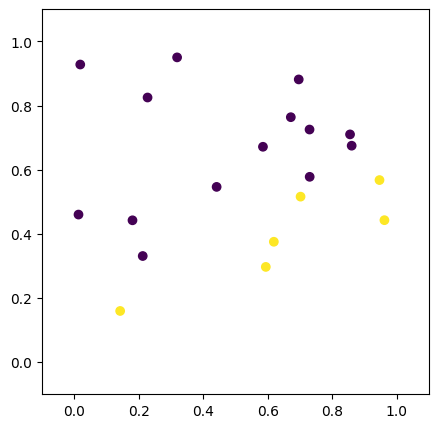

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def createDataset(n=20, coef=0.5, intercept=0.2):
  X = np.random.rand(n,2)
  y = np.array(X[:,0]*coef>(X[:,1]-intercept), dtype=int)*2-1
  return X, y

X, y = createDataset()

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.1,1.1)

plotDataset(X, y)
plt.show()

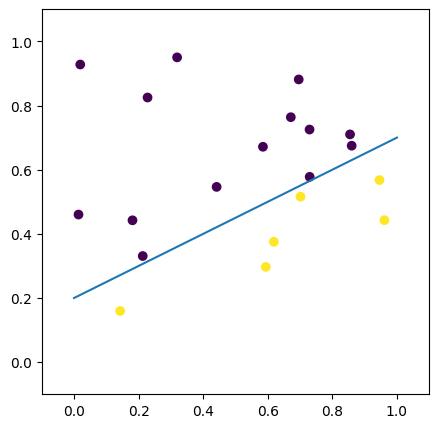

In [2]:
def plotHyperplan(vector, intercept=0):
  xs = np.array([0,1])
  ys = -(vector[0]*xs + intercept)/vector[1]
  plt.plot(xs, ys, '-')

plotDataset(X, y)
plotHyperplan(np.array([0.5,-1]), 0.2)
plt.show()


In [3]:
def include_bias(X):
  return np.hstack((np.ones((X.shape[0], 1)), X))

def sign(a):
  return (a>=0)*2-1

In [4]:
from abc import ABC, abstractstaticmethod

class Cost(ABC):
  @abstractstaticmethod
  def getCost(y, ypred):
    pass
  @abstractstaticmethod
  def getGradient(y, ypred, X):
    pass

class WidrowHoff(Cost):
  @staticmethod
  def getCost(y, ypred):
    return 0.5* ((y-ypred)**2)
  @staticmethod
  def getGradient(y, ypred, X):
    return X.T @ (y-ypred)

In [5]:
from abc import ABC, abstractmethod

class TrainingAlgorithm(ABC):
  @abstractmethod
  def getW(self, X, y):
    pass

class GradientDescent(TrainingAlgorithm):
  def __init__(self, learning_rate=0.005, n_iter=500, cost=WidrowHoff()):
    self.learning_rate = learning_rate
    self.n_iter = n_iter
    self.cost = cost

  def getW(self, X, y):
    w = np.random.uniform(size=X.shape[1])*2-1
    for _ in range(self.n_iter):
      ypred = X @ w
      w += self.learning_rate * self.cost.getGradient(y, ypred, X)
    return w

Accuracy: 0.95
Weights: [ 0.37818648  1.10015233 -2.3052771 ]


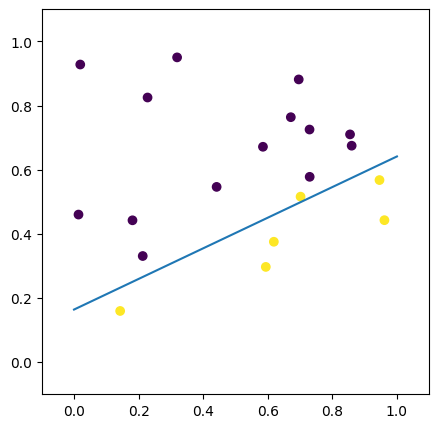

In [8]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

class NeuralNetwork(BaseEstimator, ClassifierMixin):
  def __init__(self, trainingAlgorithm=GradientDescent()):
    self.trainingAlgorithm = trainingAlgorithm

  def fit(self, X, y):
    X = include_bias(X)
    self.w_ = self.trainingAlgorithm.getW(X, y)
    return self

  def predict(self, X):
    X = include_bias(X)
    return np.sign(X @ self.w_)

widrowHoff_model = NeuralNetwork()
widrowHoff_model.fit(X, y)
ypred = widrowHoff_model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {widrowHoff_model.w_}")
plotDataset(X, y)
plotHyperplan(widrowHoff_model.w_[1:], widrowHoff_model.w_[0])
plt.show()

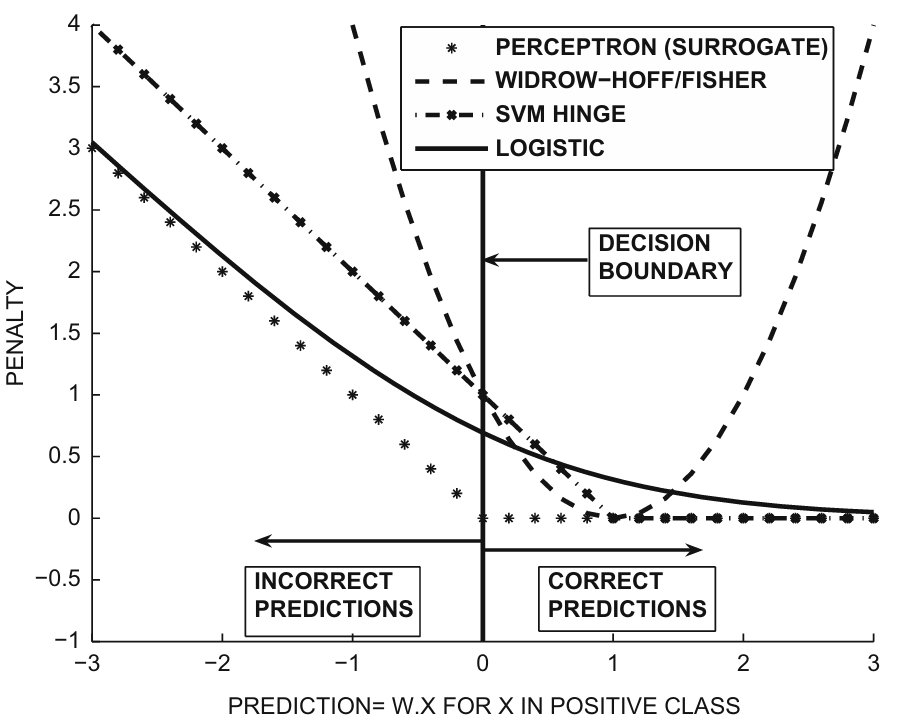

Accuracy: 1.0
Weights: [ 0.03363445  0.11410933 -0.20729626]


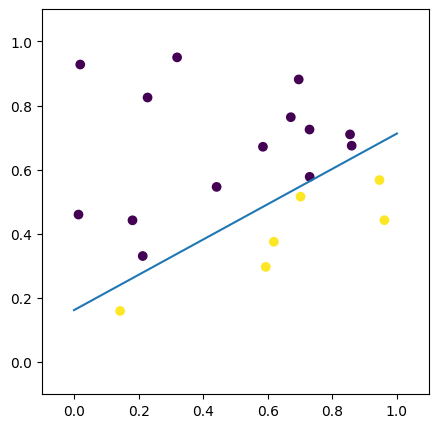

In [19]:
class SmoothedSurrogate(Cost):
  @staticmethod
  def getCost(y, ypred):
    return np.sum(np.maximum(np.zeros(y.shape), -y * ypred))
  @staticmethod
  def getGradient(y, ypred, X):
    return X.T @ (y - sign(ypred))

smoothedSurrogate_model = NeuralNetwork(
    trainingAlgorithm=GradientDescent(cost=SmoothedSurrogate()))
smoothedSurrogate_model.fit(X, y)
ypred = smoothedSurrogate_model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {smoothedSurrogate_model.w_}")
plotDataset(X, y)
plotHyperplan(smoothedSurrogate_model.w_[1:], smoothedSurrogate_model.w_[0])
plt.show()

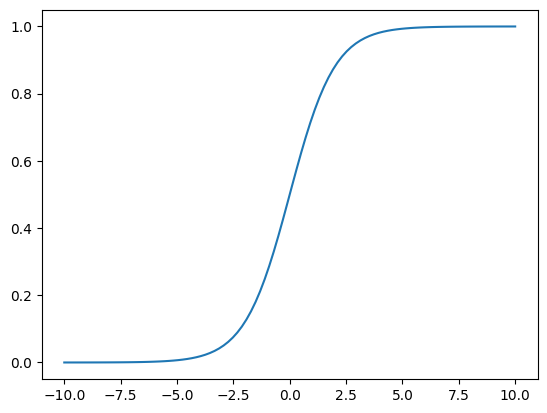

In [20]:
a = np.linspace(-10, 10, 100)
def sigmoid(a):
  return 1/(1+np.exp(-a))

plt.plot(a, sigmoid(a))
plt.show()

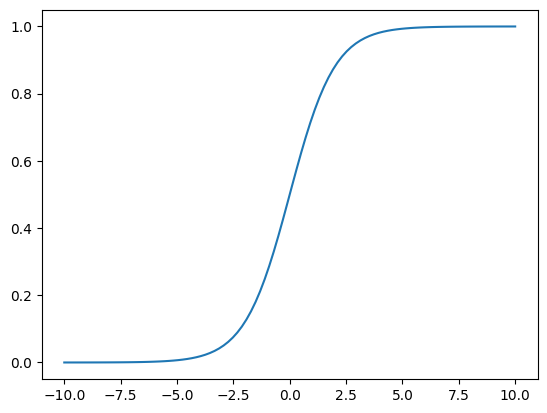

In [21]:
from scipy.special import expit

plt.plot(a, expit(a))
plt.show()

Accuracy: 0.7
Weights: [-20.99342776  -5.97137909 -17.856344  ]


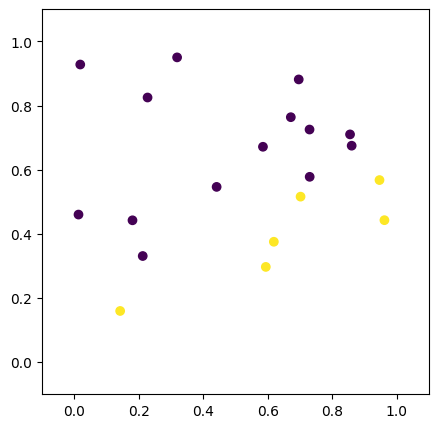

In [24]:
class LogLikehood(Cost):
  @staticmethod
  def getCost(y, ypred):
    return np.sum(np.maximum(np.zeros(y.shape), 1 - y * ypred))
  @staticmethod
  def getGradient(y, ypred, X):
    return X.T @ (y - expit(ypred))

logLikehood_model = NeuralNetwork(
    trainingAlgorithm=GradientDescent(cost=LogLikehood()))
logLikehood_model.fit(X, y)
ypred = logLikehood_model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {logLikehood_model.w_}")
plotDataset(X, y)
plotHyperplan(logLikehood_model.w_[1:], logLikehood_model.w_[0])
plt.show()

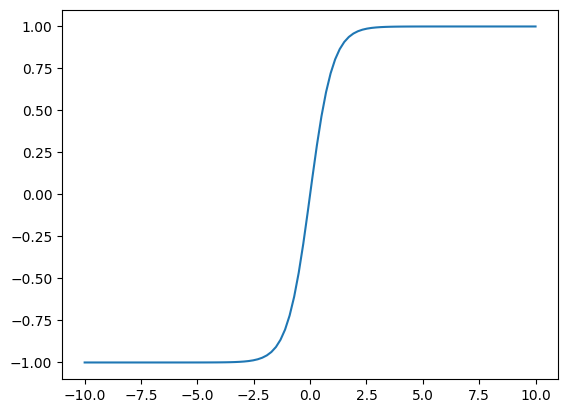

In [25]:
def tanh(a):
  return (np.exp(a)-np.exp(-a))/(np.exp(a)+np.exp(-a))
plt.plot(a, tanh(a))
plt.show()

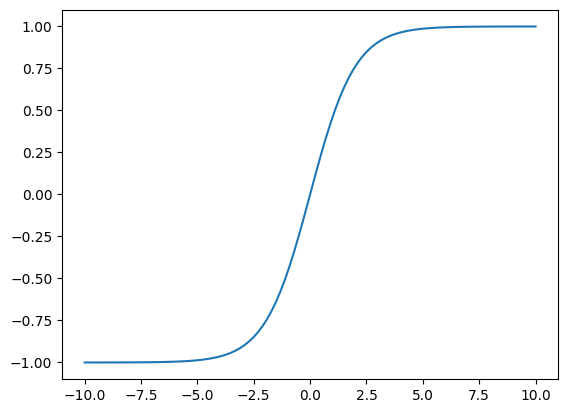

In [26]:
def fake_tanh(a):
  return expit(a)*2-1
plt.plot(a, fake_tanh(a))
plt.show()

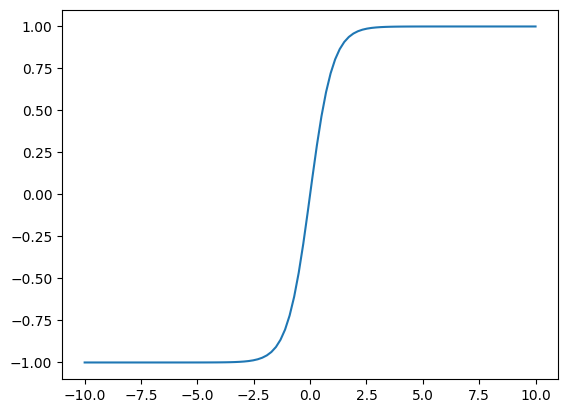

In [27]:
from numpy import tanh
plt.plot(a, tanh(a))
plt.show()

Accuracy: 0.95
Weights: [ 0.33571748  1.76019829 -3.2789433 ]


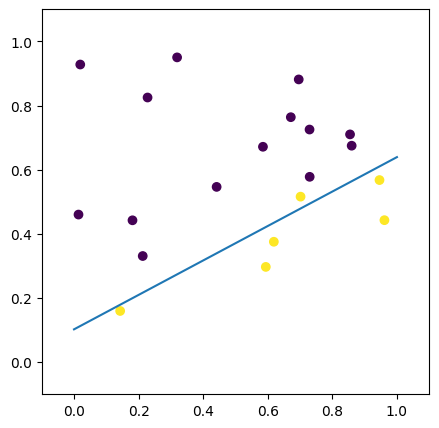

In [30]:
class LogLikehood(Cost):
  @staticmethod
  def getCost(y, ypred):
    return np.sum(np.maximum(np.zeros(y.shape), 1 - y * ypred))
  @staticmethod
  def getGradient(y, ypred, X):
    return X.T @ (y - tanh(ypred))

logLikehood_model = NeuralNetwork(
    trainingAlgorithm=GradientDescent(cost=LogLikehood()))
logLikehood_model.fit(X, y)
ypred = logLikehood_model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {logLikehood_model.w_}")
plotDataset(X, y)
plotHyperplan(logLikehood_model.w_[1:], logLikehood_model.w_[0])
plt.show()

Accuracy: 0.7
Weights: [-0.16705098  1.24411973 -2.39919451]


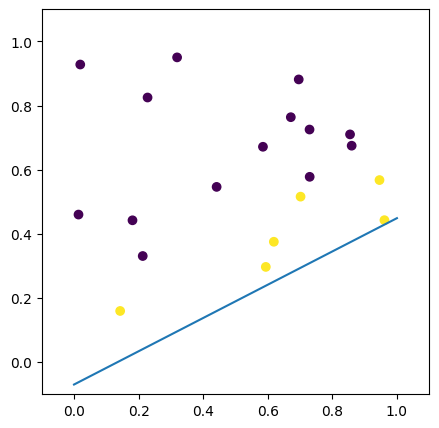

In [32]:
class HingeLoss(Cost):
  @staticmethod
  def getCost(y, ypred):
    return np.sum(np.maximum(np.zeros(y.shape), 1 - y * ypred))
  @staticmethod
  def getGradient(y, ypred, X):
    marginal_errors = (y * ypred) < 1
    marginal_ys = np.copy(y)
    marginal_ys[~marginal_errors] = 0
    return X.T @ marginal_ys

hingeLoss_model = NeuralNetwork(
    trainingAlgorithm=GradientDescent(cost=HingeLoss()))
hingeLoss_model.fit(X, y)
ypred = hingeLoss_model.predict(X)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {hingeLoss_model.w_}")
plotDataset(X, y)
plotHyperplan(hingeLoss_model.w_[1:], hingeLoss_model.w_[0])
plt.show()

Accuracy: 1.0
Weights: [ 2.39809725  0.91388508 -1.69261243]


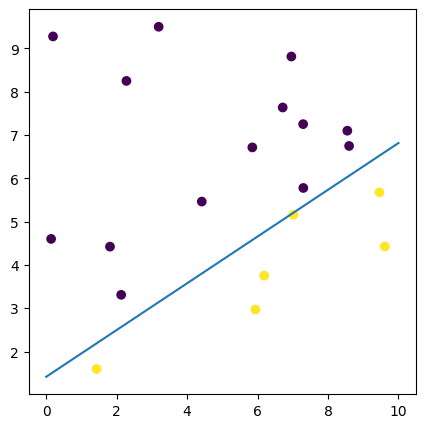

In [40]:
X10 = X*10
hingeLoss_model = NeuralNetwork(
    trainingAlgorithm=GradientDescent(cost=HingeLoss()))
hingeLoss_model.fit(X10, y)
ypred = hingeLoss_model.predict(X10)
print(f"Accuracy: {accuracy_score(y, ypred)}")
print(f"Weights: {hingeLoss_model.w_}")
plt.figure(figsize=(5,5))
plt.scatter(X10[:,0], X10[:,1], c=y)
vector, intercept = hingeLoss_model.w_[1:], hingeLoss_model.w_[0]
xs = np.array([0,10])
ys = -(vector[0]*xs + intercept)/vector[1]
plt.plot(xs, ys, '-')
plt.show()